# Chapter 2 — The diagnosis: the wild double

Chapter 1 left a gap: a naive network plateaus well short of the table, and no single knob moves it. The
most *visible* pathology in those runs is a value that never settles — the **terminal `double` action**,
whose estimate swings ±1–2 for the entire run. The final policy is therefore a snapshot of a value still
in motion.

This chapter pins that down. It shows the oscillation is real and not a fluke of one cell — we *map* it
across the whole board — rules out the obvious cause (under-sampling), and separates the two mechanisms
that could produce it. Read it as a symptom characterized precisely: Chapter 3 chases the fix and finds,
tellingly, that curing the oscillation *barely moves agreement*. Naming this suspect exactly is what lets
Chapter 3 rule it out.

In [1]:
import sys; sys.path.insert(0, '.')
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from runs import load_runs, probe_trajectory, sample_counts, learning_curve, show, provenance, describe, fignote

df = load_runs(); dqn = df[df.method == 'dqn']
# the canonical NAIVE run: onehot, constant lr, no baseline/curriculum/soft-target — the wild-double
# regime — logged with a fine-grained q-grid (2M episodes, 2000 checkpoints) so the oscillation resolves.
# (There is no 5M constant-lr run *by design*: past ~2M we always decay the step, Ch3, which removes the
# oscillation — so this is the longest, finest look at the pathology actually happening.)
naive = dqn[(dqn.encoding=='onehot') & (dqn.lr_schedule=='constant') & dqn.has_qgrid
            & (dqn.episodes==2_000_000) & (dqn.reward_baseline=='none') & (dqn.double_after==0)
            & (dqn.target_tau==0.0) & (~dqn.swa)].iloc[0]
# a matched soft/EMA-target run (the Mechanism-1 probe)
soft = dqn[(dqn.target_tau>0) & dqn.has_qgrid].iloc[0]
print('naive run agreement: %.3f' % naive.agreement, ' |', provenance(naive, role='naive exemplar'))
print('mechanism probe     :', provenance(soft, role='soft-target, otherwise matched'))

naive run agreement: 0.838  | source: naive exemplar · single run — DQN · onehot · [64, 64] · constant lr 0.001 · 2M ep · seed 42
mechanism probe     : source: soft-target, otherwise matched · single run — DQN · onehot · [64, 64] · constant lr 0.001 · 2M ep · soft-target · seed 42


## 2.1 The symptom: `Q(double)` never settles

Watch one probe cell over training — *soft-20 vs dealer-8*. `Q(stand)` is steady; `Q(double)` swings the
whole run. Doubling here is **terminal** (one card, the hand resolves) and high-variance (a ±2 stake on a
near-coin-flip), so its running estimate never converges. The final action on this cell is just where the
swing happened to sit at the last checkpoint.

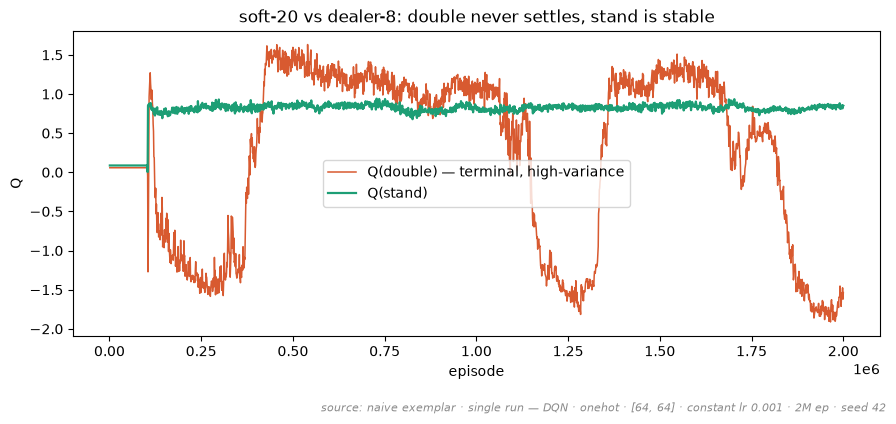

back-half std   Q(double)=1.14   vs   Q(stand)=0.03


In [2]:
ep, q_dbl = probe_trajectory(naive.path, 'soft20_v8', 'double')
_,  q_std = probe_trajectory(naive.path, 'soft20_v8', 'stand')
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ep, q_dbl, color='#D85A30', lw=1.1, label='Q(double) — terminal, high-variance')
ax.plot(ep, q_std, color='#1D9E75', lw=1.6, label='Q(stand)')
ax.set_xlabel('episode'); ax.set_ylabel('Q'); ax.set_title('soft-20 vs dealer-8: double never settles, stand is stable')
ax.legend(); plt.tight_layout(); fignote(provenance(naive, role='naive exemplar')); plt.show()
print('back-half std   Q(double)=%.2f   vs   Q(stand)=%.2f'
      % (st.pstdev(q_dbl[len(q_dbl)//2:]), st.pstdev(q_std[len(q_std)//2:])))

## 2.2 The wild double, mapped

One oscillating cell could be bad luck. It isn't — the instability is *structural*. Below, every cell on
the board is colored by the **back-half standard deviation** of its `Q(double)` and `Q(stand)` over
training (how much the value still wobbles once the agent is otherwise "done"). The double's variance
fills the entire region where doubling is a *live, marginal* option — the soft hands (13–20) and the low
hard totals (5–11) — and goes calm exactly where the action is already decided (hard 12+, where you would
never double). `Q(stand)` over the *same* cells stays far calmer everywhere. The pathology is specific to
the terminal, high-variance action, not to the network's values in general.

*(Run note: this is the 2M constant-lr run with 2000 logged checkpoints — the longest, finest-grained
look at the oscillation. There is no 5M constant-lr counterpart by design: past ~2M we always decay the
step (Chapter 3), which removes the wildness, so a longer run would have nothing left to show here.)*

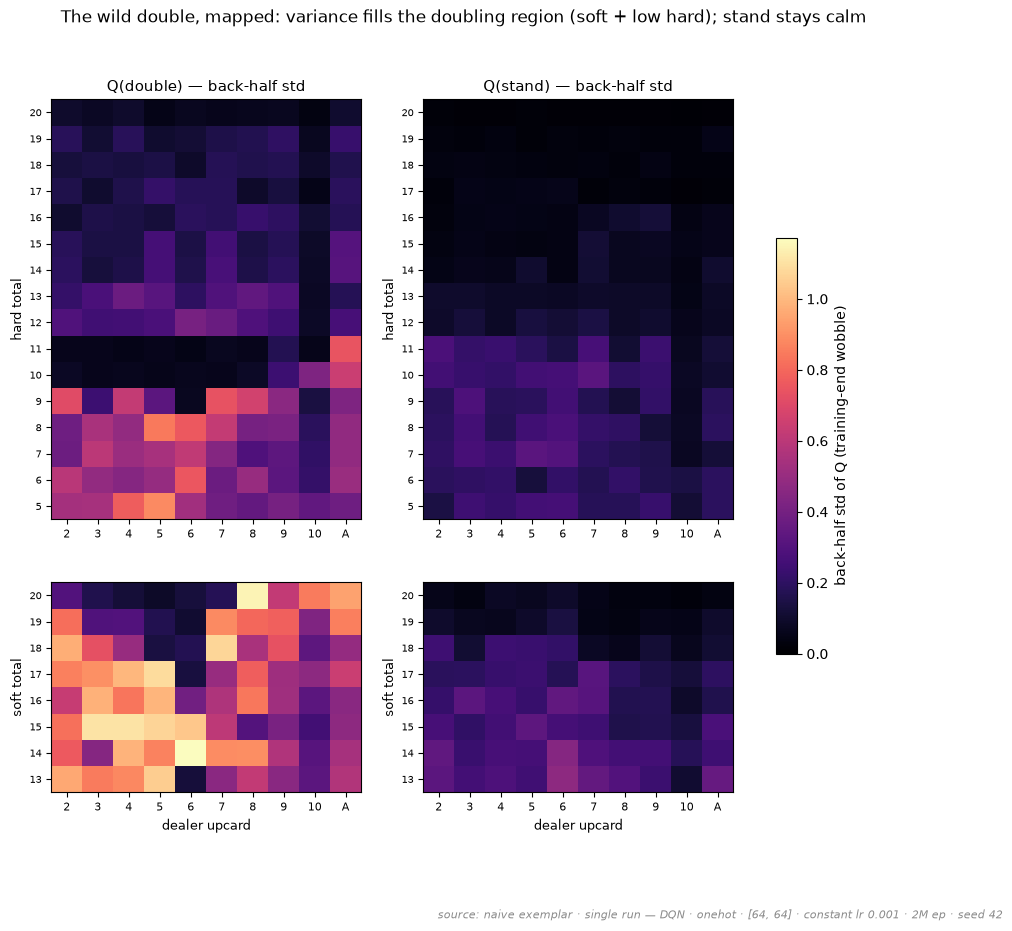

mean back-half std   Q(double)=0.39   Q(stand)=0.14   | wildest double cell: soft14_v6


In [3]:
def grid_std(path, action):
    cps = [cp['q_grid'] for cp in learning_curve(path) if cp.get('q_grid')]
    half = cps[len(cps)//2:]
    return {c: float(np.std([g[c][action] for g in half])) for c in cps[-1]}

UP = list(range(2, 12))
HARD = list(range(20, 4, -1))      # 20..5
SOFT = list(range(20, 12, -1))     # 20..13
def matrix(std, kind, totals):
    M = np.full((len(totals), len(UP)), np.nan)
    for i, t in enumerate(totals):
        for j, u in enumerate(UP):
            key = '%s%d_v%d' % (kind, t, u)
            if key in std: M[i, j] = std[key]
    return M

sd, ss = grid_std(naive.path, 'double'), grid_std(naive.path, 'stand')
vmax = max(max(sd.values()), 0.8)
fig, axes = plt.subplots(2, 2, figsize=(11, 9), gridspec_kw={'height_ratios': [16, 8]})
xlab = [str(u) if u < 11 else 'A' for u in UP]
for col, (std, name) in enumerate([(sd, 'Q(double)'), (ss, 'Q(stand)')]):
    for row, (kind, totals) in enumerate([('hard', HARD), ('soft', SOFT)]):
        ax = axes[row][col]
        im = ax.imshow(matrix(std, kind, totals), aspect='auto', cmap='magma', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(UP))); ax.set_xticklabels(xlab, fontsize=8)
        ax.set_yticks(range(len(totals))); ax.set_yticklabels(totals, fontsize=7)
        ax.set_ylabel(kind + ' total', fontsize=9)
        if row == 0: ax.set_title(name + ' — back-half std', fontsize=11)
        if row == 1: ax.set_xlabel('dealer upcard', fontsize=9)
fig.suptitle('The wild double, mapped: variance fills the doubling region (soft + low hard); stand stays calm', fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.6, label='back-half std of Q (training-end wobble)')
fignote(provenance(naive, role='naive exemplar')); plt.show()
print('mean back-half std   Q(double)=%.2f   Q(stand)=%.2f   | wildest double cell: %s'
      % (np.mean(list(sd.values())), np.mean(list(ss.values())), max(sd, key=sd.get)))

## 2.2b Is this run representative?

Every figure in this chapter is a **single run** — seed 42, the one logged at 2000-checkpoint resolution.
So is its oscillation typical? The *phenomenon* is: every constant-lr run oscillates, and decaying the step
clearly calms it. But this exemplar sits near the **top** of the spread — we use it because it is the most
finely logged. The table below marks where it sits, so the amplitude on screen reads in context: the
qualitative pattern (which cells swing) is general; the height is high-end.

In [4]:
osc = dqn[(~dqn.with_splits) & dqn.soft20_double_std.notna()].copy()
osc['lr'] = osc.lr_schedule.map(lambda s: 'constant (naive)' if s == 'constant' else 'decaying')
summary = (osc.groupby('lr').soft20_double_std
              .agg(n='count', median='median', mean='mean', min='min', max='max').reset_index())
show(summary, num=['median', 'mean', 'min', 'max'],
     caption='Oscillation (back-half std of Q(double) on soft-20 v8) across ALL no-split DQN runs — '
             'the pathology is general; decay calms it (previews Ch3).',
     source='source: every no-split DQN run with this probe logged (%d runs: %d constant, %d decaying)'
            % (len(osc), (osc.lr=='constant (naive)').sum(), (osc.lr=='decaying').sum()))
print("this chapter's exemplar sits at %.2f — near the top of the constant-lr spread (median %.2f)"
      % (naive.soft20_double_std, osc[osc.lr == 'constant (naive)'].soft20_double_std.median()))

lr,n,median,mean,min,max
constant (naive),41,0.52,0.59,0.15,1.34
decaying,24,0.19,0.31,0.06,1.01


this chapter's exemplar sits at 1.14 — near the top of the constant-lr spread (median 0.52)


## 2.3 Not data quantity — and two failures, not one

The natural next guess is that the swinging cells are starved of data. The counts complicate that story,
usefully. Put each cell's oscillation amplitude (back-half std of `Q(double)`) next to its visit counts:

In [5]:
sc = sample_counts(naive.path)
cps = [cp['q_grid'] for cp in learning_curve(naive.path) if cp.get('q_grid')]
half = cps[len(cps)//2:]
import numpy as np
def row(label, key, correct, v, sf, u):
    return {'cell': label,
            'double': sc.get((v,sf,u,'double'),0), 'stand': sc.get((v,sf,u,'stand'),0), 'hit': sc.get((v,sf,u,'hit'),0),
            'std Q(dbl)': float(np.std([g[key]['double'] for g in half])),
            'correct': correct, 'agent plays': max(cps[-1][key], key=cps[-1][key].get)}
rows = [row('soft-20 v8  (oscillates)',     'soft20_v8', 'stand',  20, True,  8),
        row('soft-20 v6  (over-doubles)',   'soft20_v6', 'stand',  20, True,  6),
        row('hard-11 v6  (correct double)', 'hard11_v6', 'double', 11, False, 6)]
show(pd.DataFrame(rows), num=['std Q(dbl)'],
     caption='Two failures side by side: soft-20 v8 oscillates (high std) on the FEWEST samples yet lands right; '
             'soft-20 v6 over-doubles STABLY (low std) on more samples. Neither is fixed by data quantity.',
     source=provenance(naive, role='naive exemplar'))

cell,double,stand,hit,std Q(dbl),correct,agent plays
soft-20 v8 (oscillates),822,1948,193,1.14,stand,stand
soft-20 v6 (over-doubles),1604,446,141,0.13,stand,double
hard-11 v6 (correct double),6186,679,1075,0.05,double,double


## 2.3b What the table actually shows

Two distinct failures sit side by side. *soft-20 v8* genuinely **oscillates** (std 1.14) on the *fewest*
samples — yet it still lands on the correct action. *soft-20 v6* does the opposite: it **over-doubles
stably** (std 0.13) on *more* samples and stays wrong — a bias, not a wobble. The original "oscillating
*or* wrong" framing quietly merged a *variance* failure with a *bias* failure; they are different things.

On under-sampling specifically: across all 240 cells the oscillation amplitude is only weakly tied to
sample count (r ≈ -0.31) — the least-sampled marginal cells do swing most. But the swing is not *caused*
by the count. These cells have hundreds-to-thousands of visits, and the decisive test is Chapter 3: a
decaying step settles the same cell on the *same data budget*. If quantity were the lever, fixing the
budget and changing only the step couldn't help — it does. Count merely tracks which cells are marginal;
the step schedule decides whether they converge. The stable over-double, meanwhile, is a *representation*
limit — Chapter 4. This table is where those two threads first separate.

## 2.4 Two mechanisms, told apart by experiment

Two things could keep the value moving:

- **Mechanism 1 — feedback loop:** the estimate picks the action, which picks the data, which feeds back
  into the estimate. Anything that stabilizes the bootstrap or the data would damp it.
- **Mechanism 2 — constant-gain variance:** a running mean of a high-variance reward under a *constant*
  learning rate has non-vanishing steady-state variance. It converges to a *distribution*, not a point.

A soft / EMA target network damps Mechanism 1. If the double were a feedback-loop problem, it would
settle. It doesn't — because `double` is **terminal**: its target is the raw ±2 reward, so the target
network was never in its path. The soft target shrinks the swing but leaves it wild (well above a calm
`Q(stand)`), isolating Mechanism 2. (Exploring starts, which force uniform data, likewise fail to settle
it — same conclusion, Chapter 3.)

In [6]:
def bh(path, cell, act):
    _, v = probe_trajectory(path, cell, act); return st.pstdev(v[len(v)//2:])
comp = pd.DataFrame([
    {'setting': 'constant lr',             'action': 'double', 'back-half std': bh(naive.path, 'soft20_v8', 'double')},
    {'setting': 'soft / EMA target',       'action': 'double', 'back-half std': bh(soft.path,  'soft20_v8', 'double')},
    {'setting': 'constant lr (for scale)', 'action': 'stand',  'back-half std': bh(naive.path, 'soft20_v8', 'stand')},
])
show(comp, num=['back-half std'],
     caption='soft-20 v8: a soft target shrinks the swing but does not settle it (vs a calm stand) → not the feedback loop',
     source='source: two matched single runs — ' + describe(naive) + ' (the second run is identical, plus a soft-target)')

setting,action,back-half std
constant lr,double,1.14
soft / EMA target,double,0.65
constant lr (for scale),stand,0.03


## 2.5 Conclusion

The naive runs carry an oscillating value on the terminal `double`: a high-variance reward learned with a
constant-gain step, so the estimate never converges — and it is a *structural* band across the live-doubling region,
not one unlucky cell. Its data *budget* is not the lever — more samples do not settle it (Chapter 3 does, on the same budget) — and it is **not** the feedback loop. The tabular learner
avoided it for free: its `1/n` step shrinks over time, so its averages converge; the network's constant
Adam step does not.

The obvious fix is to make the step decay — Chapter 3. But hold the verdict loosely: there, settling the double (pushing the step low) barely moves agreement — if anything it costs a little (the tightest-settling run lands at 0.81, just under the oscillating baseline's 0.83), while the runs that score higher get there by reaching (a higher step that leaves the double noisy, 0.89), not by settling. A variance we can see and fix
turns out not to be the binding constraint. The thing that actually caps agreement is waiting in Chapters
3–4.